# 03 — Fitting a Stacked Spectrum

Stacked (co-added) spectra don't come from a single grating, so the
resolving power must be specified manually or auto-estimated from
the pixel spacing.

This notebook shows:
1. Loading a `.npz` stacked spectrum
2. Fitting Hα + [NII] + [OIII] 5007 with a user-specified R
3. Broad component fitting via BIC model selection
4. Interactive plotly visualisation
5. Auto-detected R from pixel spacing
6. IGM transmission model for Lyman-alpha

In [1]:
import jwspecfit
from jwspecfit.lyman_alpha import igm_transmission
import matplotlib.pyplot as plt
import numpy as np

## Load the stacked spectrum

This is a rest-frame UV stack of 129 galaxies at z ~ 6, with
wavelengths in Angstroms and flux in arbitrary units.

R(λ) is estimated from the pixel spacing using `R_from_pixels`.

13000 pixels
Wave: 1000 – 7500 Å
N stacked: 129


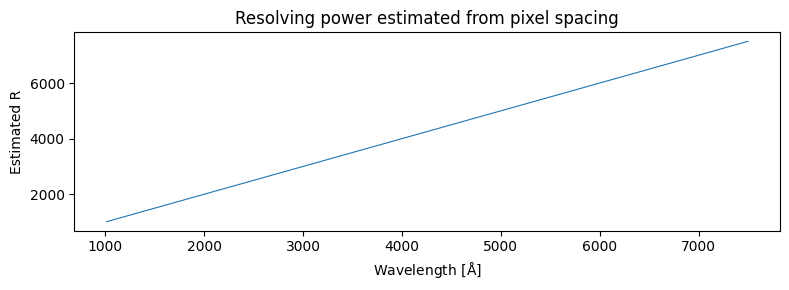

In [2]:
stack = jwspecfit.read_npz(
    "../../data/stack_all_Muv19_21_DustCorrected.npz",
    z=0.0,     # already in rest frame
)

# Estimate R from pixel spacing (no grating info for stacks)
R_fn = jwspecfit.R_from_pixels(stack.wave_um)
stack.R = R_fn

print(f"{stack.n_pix} pixels")
print(f"Wave: {stack.wave_A.min():.0f} – {stack.wave_A.max():.0f} Å")
print(f"N stacked: {stack.meta.get('n_stacked', '?')}")

# Show estimated R(λ)
valid = stack.mask_valid()
R_est = R_fn(stack.wave_um)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(stack.wave_A[valid], R_est[valid], lw=0.8)
ax.set_xlabel(r"Wavelength [$\mathrm{\AA}$]")
ax.set_ylabel("Estimated R")
ax.set_title("Resolving power estimated from pixel spacing")
plt.tight_layout()

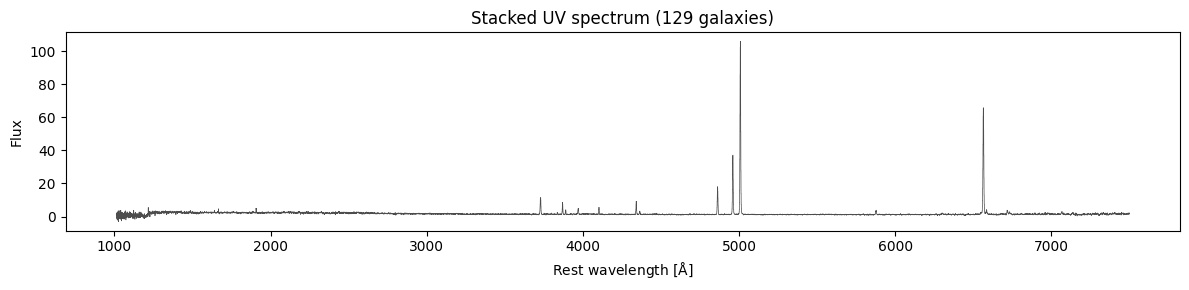

In [3]:
# Quick look — mask NaN regions
valid = stack.mask_valid()

fig, ax = plt.subplots(figsize=(12, 3))
ax.step(stack.wave_A[valid], stack.flux_ujy[valid], where="mid", lw=0.5, color="0.3")
ax.set_xlabel(r"Rest wavelength [$\mathrm{\AA}$]")
ax.set_ylabel("Flux")
ax.set_title("Stacked UV spectrum (129 galaxies)")
plt.tight_layout()

## Fit Hα + [NII] + [OIII] 5007

Fit the optical emission lines in the rest-frame stack using
the pixel-estimated R(λ).

In [5]:
optical_lines = ["HBETA","OIII_5007", "Ha", "NII_6549", "NII_6585"]

result_opt = jwspecfit.fit_with_broad(
    stack, z=0.0,
    lines=optical_lines,
    mode="auto"
)

print(f"Selected model: {result_opt.selected_model}")
print(f"BIC — narrow: {result_opt.bic_narrow:.1f}, broad1: {result_opt.bic_broad1:.1f}, "
      f"broad2: {result_opt.bic_broad2:.1f}, both: {result_opt.bic_both:.1f}")
print(f"\nχ²/dof = {result_opt.best_fit.chi2:.2f}")
print()
for name, lr in result_opt.best_fit.lines.items():
    print(f"  {name:<18s} flux={lr.flux:.3e} ± {lr.flux_err:.3e}  SNR={lr.snr:.1f}")

Bootstrap (broad1): 100%|██████████| 1000/1000 [00:48<00:00, 20.42iter/s]

Selected model: broad1
BIC — narrow: 712.0, broad1: 641.0, broad2: 656.7, both: 645.8

χ²/dof = 0.90

  HBETA              flux=9.527e-17 ± 4.680e-18  SNR=20.4
  OIII_5007          flux=7.313e-16 ± 1.559e-17  SNR=46.9
  Ha                 flux=2.794e-16 ± 7.875e-18  SNR=35.5
  NII_6549           flux=3.073e-18 ± 5.248e-19  SNR=5.9
  NII_6585           flux=9.096e-18 ± 1.553e-18  SNR=5.9
  Ha_BROAD           flux=2.196e-17 ± 5.742e-18  SNR=3.8
  HBETA_BROAD        flux=2.395e-17 ± 3.744e-18  SNR=6.4


/Users/raunaqrai/miniforge3/envs/jwst/lib/python3.12/site-packages/jwspecfit/plotting.py:284: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


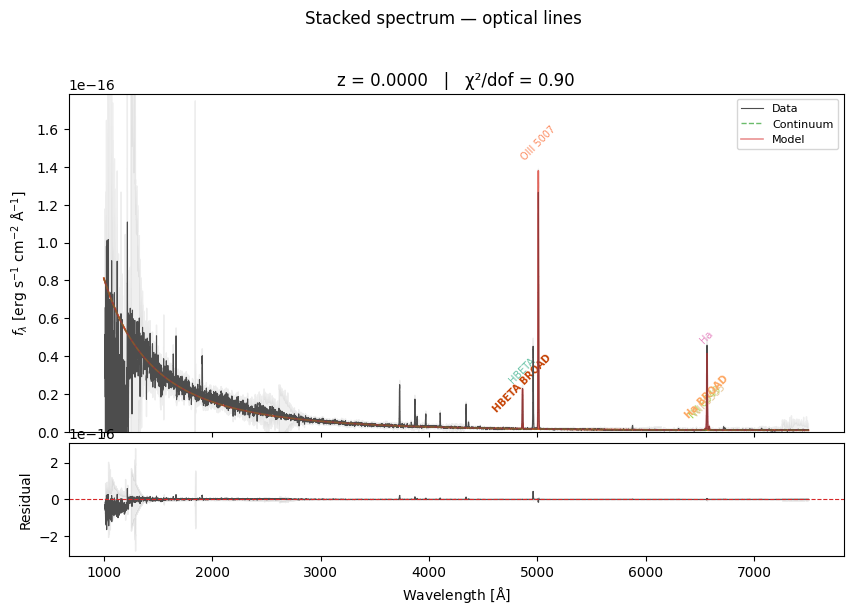

In [6]:
# Matplotlib plot
fig = jwspecfit.plot_fit(result_opt.best_fit, wave_unit="A",flux_unit="flam")
fig.suptitle("Stacked spectrum — optical lines", y=1.02)
plt.show()

In [7]:
# Interactive plotly plot
fig_interactive = jwspecfit.plot_fit_interactive(result_opt.best_fit, wave_unit="A")
fig_interactive.show()